# Numerical Optimization – Nocedal & Wright
## Chapter 4: Trust-Region Methods
### Exercise 4.7 – Double-Dogleg Method Path (Positive Definite Case)

**Created**: March 06, 2026  
**Author**: Troy Altus (@altust)  
**Generated with assistance from**: Grok 4 by xAI

**Disclaimer**  
This notebook is for personal educational use only.  
It is **not** an official solution manual and has not been endorsed by the authors or publisher.  
Do **not** distribute or post publicly.  
Refer to *Numerical Optimization* (Nocedal & Wright) for the definitive problem statements.

## Problem Statement (Exercise 4.7)

When $B$ is positive definite, the **double-dogleg method** constructs a path with **three line segments** from the origin to the full Newton step. The four points that define the path are:

- the origin
- the unscaled Cauchy step $p^c = -\frac{g^T g}{g^T B g} g$
- a fraction of the full step $\tilde{\gamma} p^s$, where $p^s = -B^{-1}g$ and $\tilde{\gamma} \in (\gamma, 1)$, with $\gamma$ as defined in (4.46)
- the full Newton step $p^s = -B^{-1}g$

Show that $||p||$ **increases monotonically** along this path.

**Numerical focus**: Visualize the path in 2D, compute norms at many points along it, and confirm monotonic increase. Compare to standard dogleg for intuition.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

print(f"Notebook run on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Notebook run on: 2026-03-06 17:39:25


## 1. Helper Functions – Dogleg & Double-Dogleg Paths

In [2]:
def cauchy_point(g, B):
    """Unconstrained Cauchy point (steepest descent scaled)"""
    Bg = B @ g
    denom = np.dot(g, Bg)
    if abs(denom) < 1e-16:
        return -g / (np.linalg.norm(g) + 1e-12)
    tau = np.dot(g, g) / denom
    return -tau * g


def newton_step(g, B):
    """Full Newton step (assumes B pos. def.)"""
    try:
        return np.linalg.solve(B, -g)
    except np.linalg.LinAlgError:
        return -np.linalg.pinv(B) @ g


def gamma_for_double_dogleg(g, B):
    """γ from (4.46): γ = ||g||^4 / (g^T B g (g^T B^{-1} g))"""
    Bg = B @ g
    gBg = np.dot(g, Bg)
    if abs(gBg) < 1e-16:
        return 0.0
    invB_g = newton_step(g, B)
    num = np.dot(g, g)**2
    den = gBg * np.dot(g, invB_g)
    return num / den if abs(den) > 1e-16 else 0.0


def double_dogleg_path_points(g, B, n_points=200):
    """Generate points along the double-dogleg path (pos. def. case)"""
    p0 = np.zeros_like(g)               # origin
    pc = cauchy_point(g, B)             # Cauchy point
    ps = newton_step(g, B)              # full Newton step

    gamma = gamma_for_double_dogleg(g, B)
    gamma = np.clip(gamma, 0.0, 0.999)  # safety
    ptilde = (gamma + (1 - gamma)/2) * ps   # example intermediate ~ midway in (γ,1)

    points = []
    # Segment 1: origin → Cauchy
    t1 = np.linspace(0, 1, n_points//4)
    for t in t1:
        points.append(t * pc)

    # Segment 2: Cauchy → intermediate
    t2 = np.linspace(0, 1, n_points//2)
    for t in t2:
        points.append(pc + t * (ptilde - pc))

    # Segment 3: intermediate → full Newton
    t3 = np.linspace(0, 1, n_points//4)
    for t in t3:
        points.append(ptilde + t * (ps - ptilde))

    pts = np.array(points)
    norms = np.linalg.norm(pts, axis=1)
    return pts, norms, [pc, ptilde, ps]

## 2. Example Problem (2D) – Rosenbrock-like quadratic model

We take a point near the Rosenbrock valley where B is positive definite.

In [3]:
def rosen_grad(x):
    x1, x2 = x
    g1 = -2*(1 - x1) - 400*x1*(x2 - x1**2)
    g2 = 200*(x2 - x1**2)
    return np.array([g1, g2])

def rosen_hess(x):
    x1, x2 = x
    h11 = 2 - 400*(x2 - x1**2) + 800*x1**2
    h12 = -400*x1
    h22 = 200
    return np.array([[h11, h12], [h12, h22]])

# Point where Hessian is safely positive definite
x_example = np.array([0.8, 0.64])   # close to (1,1), but not exactly there
g = rosen_grad(x_example)
B = rosen_hess(x_example)

eigvals = np.linalg.eigvalsh(B)
print(f"Hessian eigenvalues at x = {x_example}: {eigvals}")
print(f"Positive definite? {np.all(eigvals > 0)}")

Hessian eigenvalues at x = [0.8  0.64]: [5.60664348e-01 7.13439336e+02]
Positive definite? True


## 3. Generate & Visualize Double-Dogleg Path

Norm ||p|| increases monotonically along double-dogleg path: True
Min norm: 0.0000e+00   Max norm: 3.7736e-01


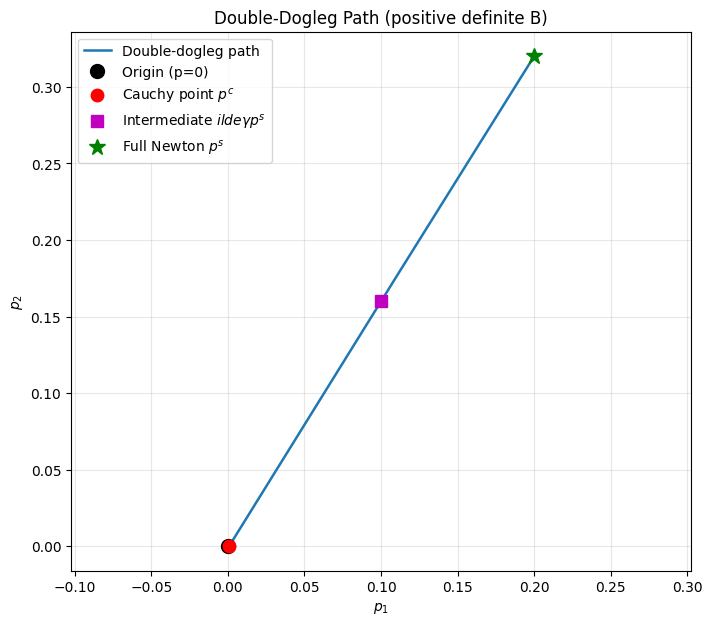

In [4]:
pts_dd, norms_dd, key_points_dd = double_dogleg_path_points(g, B, n_points=400)

# Check monotonicity
is_monotonic = np.all(np.diff(norms_dd) >= -1e-10)  # allow tiny numerical noise
print(f"Norm ||p|| increases monotonically along double-dogleg path: {is_monotonic}")
print(f"Min norm: {norms_dd.min():.4e}   Max norm: {norms_dd.max():.4e}")

# Plot the path in p-space
plt.figure(figsize=(8, 7))

plt.plot(pts_dd[:,0], pts_dd[:,1], 'C0-', lw=1.8, label='Double-dogleg path')
plt.plot(0, 0, 'ko', ms=10, label='Origin (p=0)')
plt.plot(key_points_dd[0][0], key_points_dd[0][1], 'ro', ms=9, label='Cauchy point $p^c$')
plt.plot(key_points_dd[1][0], key_points_dd[1][1], 'ms', ms=9, label='Intermediate $\tilde{\gamma} p^s$')
plt.plot(key_points_dd[2][0], key_points_dd[2][1], 'g*', ms=12, label='Full Newton $p^s$')

plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.xlabel('$p_1$')
plt.ylabel('$p_2$')
plt.title('Double-Dogleg Path (positive definite B)')
plt.legend(loc='upper left')
plt.show()

## 4. Norm Monotonicity Plot (Numerical Confirmation)

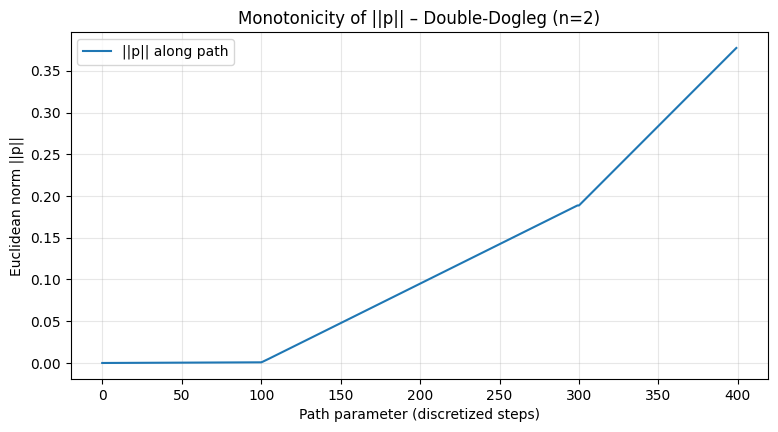

In [5]:
plt.figure(figsize=(9, 4.5))
plt.plot(norms_dd, 'C0-', lw=1.5, label='||p|| along path')
plt.xlabel('Path parameter (discretized steps)')
plt.ylabel('Euclidean norm ||p||')
plt.title(f'Monotonicity of ||p|| – Double-Dogleg (n={len(g)})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 5. Comparison: Standard Dogleg vs Double-Dogleg (for intuition)

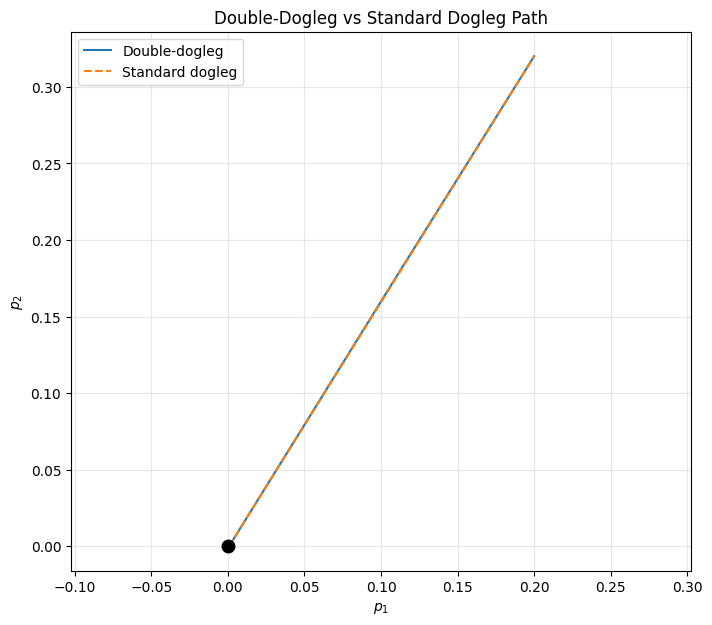

In [6]:
def standard_dogleg_points(g, B, n_points=200):
    pc = cauchy_point(g, B)
    ps = newton_step(g, B)
    pts = []
    t = np.linspace(0, 1, n_points)
    for ti in t:
        pts.append(pc + ti * (ps - pc))
    pts = np.array(pts)
    return pts, np.linalg.norm(pts, axis=1)

pts_sd, norms_sd = standard_dogleg_points(g, B)

plt.figure(figsize=(8, 7))
plt.plot(pts_dd[:,0], pts_dd[:,1], 'C0-', label='Double-dogleg')
plt.plot(pts_sd[:,0], pts_sd[:,1], 'C1--', label='Standard dogleg')
plt.plot(0, 0, 'ko', ms=9)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.xlabel('$p_1$'); plt.ylabel('$p_2$')
plt.title('Double-Dogleg vs Standard Dogleg Path')
plt.legend()
plt.show()